# Pipeline Walkthrough — A Lending-Lifecycle Fairness Benchmark

A narrated tour of how this repository actually works, from raw CSVs to the
LLM benchmark results.

**Everything here runs offline.** No API key, no network, no LLM call. Every
cell reads committed or regenerable files. If a cell needs something absent, it
says so and continues rather than failing.

Sections:

1. Architecture: `run_pipeline.py` and the dataset registry
2. Cleaning and encoding decisions, per dataset
3. The fairness metric layer — and the favorable-label lesson
4. The qualitative engine: severity, root causes, proxies, evidence retention
5. The LLM benchmark: 4 cycles, frozen packs, scoring, detectors
6. Results gallery

In [1]:
import json, os, sys
from pathlib import Path
import pandas as pd

# Resolve the repo root whether this runs from notebooks/ or the repo root.
ROOT = Path.cwd()
if not (ROOT / "run_pipeline.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "run_pipeline.py").exists(), f"cannot locate repo root from {Path.cwd()}"
# scripts/ for the pipeline modules, ROOT for run_pipeline itself.
sys.path.insert(0, str(ROOT / "scripts"))
sys.path.insert(0, str(ROOT))

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("repo root:", ROOT)
print("python    :", sys.version.split()[0])

repo root: /Users/siddhant/Desktop/Previous Coursework/CMPT 310/Group Project/AI-fairness-dashboard/.claude/worktrees/hopeful-wright-f024e8
python    : 3.11.14


---
## 1. Architecture: `run_pipeline.py` and the dataset registry

The orchestrator is a registry plus a step runner. Each dataset declares a
working directory and a shell command per step; steps run in a fixed order as
subprocesses, and a failing step stops that dataset without killing the others.

Two things about this design matter downstream and are easy to miss.

In [2]:
import run_pipeline as rp

print("STEP_ORDER:", rp.STEP_ORDER)
print()
print(f"{'dataset':22s} {'dir':26s} steps")
for key, cfg in rp.DATASETS.items():
    print(f"{key:22s} {cfg['dir']:26s} {sorted(cfg['steps'])}")

STEP_ORDER: ['clean', 'train', 'fairness', 'qualitative', 'llm_benchmark', 'benchmark', 'visualize']

dataset                dir                        steps
german_credit          german_credit_dataset      ['benchmark', 'clean', 'fairness', 'legacy_gemini_benchmark', 'llm_benchmark', 'qualitative', 'train']
hmda                   hmda_dataset               ['benchmark', 'clean', 'fairness', 'legacy_gemini_benchmark', 'llm_benchmark', 'qualitative', 'train']
lending_club           lending_club_dataset       ['benchmark', 'clean', 'fairness', 'llm_benchmark', 'qualitative', 'train']
healthcare_insurance   Healthcare-insurance-dataset ['clean', 'fairness', 'qualitative', 'train']
diabetes               diabetes_dataset           ['clean', 'fairness', 'qualitative', 'train']


**Note the asymmetry.** The step named `benchmark` runs the 4-cycle Track Q
harness (`scripts/llm_benchmark.py`), while the step named `llm_benchmark` runs
the Track H narrative audit (`scripts/openai_fairness_analysis.py`). The names
are the reverse of what you would guess, which is worth knowing before you
invoke either.

Only the three lending datasets carry both; `healthcare_insurance` and
`diabetes` are registered for the deterministic layer only.

In [3]:
# The consolidation footgun, stated explicitly because it silently corrupts artifacts.
print(rp.consolidate.__doc__ or "(no docstring)")
print()
print("consolidate() rebuilds cross-dataset files from ONLY the datasets passed")
print("via --datasets. Running a subset leaves artifacts/consolidated/ and")
print("poster_assets/ holding that subset. Always pass all three:")
print()
print("  python3.11 run_pipeline.py --datasets german_credit hmda lending_club --steps qualitative")

Copy artifacts and merge cross-dataset reports.

consolidate() rebuilds cross-dataset files from ONLY the datasets passed
via --datasets. Running a subset leaves artifacts/consolidated/ and
poster_assets/ holding that subset. Always pass all three:

  python3.11 run_pipeline.py --datasets german_credit hmda lending_club --steps qualitative


---
## 2. Cleaning and encoding decisions, per dataset

Each dataset needed a different fix before fairness metrics meant anything.

In [4]:
gc_path = ROOT / "german_credit_dataset" / "data" / "german_credit_CLEANED_dataset.csv"
if gc_path.exists():
    gc = pd.read_csv(gc_path)
    print("German Credit:", gc.shape)
    # The target ships as 1 = good credit, 2 = bad credit — NOT 0/1.
    target_col = "Cost Matrix(Risk)" if "Cost Matrix(Risk)" in gc.columns else gc.columns[-1]
    print(f"\nraw target '{target_col}' value counts:")
    print(gc[target_col].value_counts().sort_index().to_string())
    print("\n1 = good credit (favorable), 2 = bad credit.")
    print("Mapped to 1/0 during training; treating the raw 1/2 as 0/1 would invert")
    print("the favorable class and therefore invert every fairness metric.")
else:
    print("German Credit cleaned CSV not present; run `make fairness` to regenerate.")

German Credit: (1000, 14)

raw target 'credit risk' value counts:
credit risk
1    700
2    300

1 = good credit (favorable), 2 = bad credit.
Mapped to 1/0 during training; treating the raw 1/2 as 0/1 would invert
the favorable class and therefore invert every fairness metric.


In [5]:
# Lending Club: protected attributes arrive one-hot encoded and must be decoded
# back to a single categorical column before per-group rates can be computed.
enriched = ROOT / "lending_club_dataset" / "metrics" / "classification_predictions_enriched.csv"
if enriched.exists():
    lc = pd.read_csv(enriched)
    print("Lending Club enriched predictions:", lc.shape)
    for col in ["gender", "income_level", "loan_amount_level"]:
        if col in lc.columns:
            print(f"\n{col}:")
            print(lc[col].value_counts().to_string())
    print("\nThese three columns are produced by prepare_qualitative_inputs.py,")
    print("which decodes the one-hot columns the model was trained on. The raw")
    print("processed/ matrices have no single 'gender' column to group by.")
else:
    print("Enriched predictions not present (metrics/ is gitignored).")
    print("Regenerate: python3.11 run_pipeline.py --datasets lending_club --steps qualitative")

Lending Club enriched predictions: (600, 42)

gender:
gender
male      312
female    288

income_level:
income_level
medium    278
low       183
high      139

loan_amount_level:
loan_amount_level
medium    320
small     181
large      99

These three columns are produced by prepare_qualitative_inputs.py,
which decodes the one-hot columns the model was trained on. The raw
processed/ matrices have no single 'gender' column to group by.


---
## 3. The fairness metric layer — and the favorable-label lesson

This is the most important section in the notebook. A single convention —
*which label counts as the favorable outcome* — moved a headline metric from
"maximally alarming" to "unremarkable".

Lending Club's target is `loan_default`, so **label 1 is the *unfavorable*
outcome.** Disparate impact is a ratio of *favorable* selection rates. Computing
it on predicted defaults answers the wrong question.

Let's reproduce both numbers from the committed predictions.

In [6]:
if enriched.exists():
    lc = pd.read_csv(enriched)
    priv, unpriv = "male", "female"

    def selection_rate(df, group, favorable_label):
        sub = df[df["gender"] == group]
        return (sub["predicted"] == favorable_label).mean()

    print("Group sizes:", lc["gender"].value_counts().to_dict())
    print()

    # WRONG: orient on label 1 (= predicted default, the ADVERSE event)
    m_def = selection_rate(lc, priv, 1)
    f_def = selection_rate(lc, unpriv, 1)
    di_wrong = (f_def / m_def) if m_def else float("inf") if f_def else float("nan")
    print("Oriented on label 1 (predicted DEFAULT) — the bug:")
    print(f"   male   rate = {m_def:.4f}")
    print(f"   female rate = {f_def:.4f}")
    print(f"   DI = {m_def:.4f} / {f_def:.4f} = {(m_def / f_def) if f_def else 0.0:.4f}   <-- reads CRITICAL")
    print()

    # RIGHT: orient on label 0 (= predicted non-default, the FAVORABLE outcome)
    m_ok = selection_rate(lc, priv, 0)
    f_ok = selection_rate(lc, unpriv, 0)
    print("Oriented on label 0 (predicted NON-DEFAULT) — the fix:")
    print(f"   male   rate = {m_ok:.4f}")
    print(f"   female rate = {f_ok:.4f}")
    print(f"   DI = {f_ok:.4f} / {m_ok:.4f} = {f_ok / m_ok:.4f}   <-- near parity")
else:
    print("Enriched predictions unavailable; showing the committed values instead.")
    print("  default-oriented : DI = 0.0000  (male 0.0000 vs female 0.0069)")
    print("  favorable-oriented: DI = 0.9931  (male 1.0000 vs female 0.9931)")

Group sizes: {'male': 312, 'female': 288}

Oriented on label 1 (predicted DEFAULT) — the bug:
   male   rate = 0.0000
   female rate = 0.0069
   DI = 0.0000 / 0.0069 = 0.0000   <-- reads CRITICAL

Oriented on label 0 (predicted NON-DEFAULT) — the fix:
   male   rate = 1.0000
   female rate = 0.9931
   DI = 0.9931 / 1.0000 = 0.9931   <-- near parity


**The same model, the same data, the same correct metric implementation — and a
factor-of-infinity difference in the headline number.**

Nothing exotic caused this. The target variable is named for the adverse event,
which is completely normal in credit risk, and the toolkit default assumes label
1 is favorable. This is now pinned by `tests/test_lending_club_fairness.py`,
including a test asserting that the default-oriented computation *would* read
zero — so the bug cannot silently return.

In [7]:
# The committed metrics, straight from the consolidated CSV.
cons = ROOT / "artifacts" / "consolidated" / "consolidated_fairness_metrics.csv"
df = pd.read_csv(cons)
# NOTE: this file carries two disjoint column schemas — german_credit/hmda use
# CamelCase, lending_club uses snake_case — because consolidation concatenates
# per-dataset CSVs without harmonising them. A known artifact defect.
upper = df[df["DisparateImpact"].notna()][
    ["Dataset", "Attribute", "PrivilegedValue", "DisparateImpact",
     "EqualOpportunityDiff", "AverageOddsDiff"]
]
lower = df[df["disparate_impact"].notna()][
    ["Dataset", "protected_attribute", "privileged_group", "disparate_impact",
     "equal_opportunity_difference", "average_odds_difference"]
]
print("german_credit + hmda:"); print(upper.to_string(index=False))
print("\nlending_club (different column names — see note above):")
print(lower.to_string(index=False))

german_credit + hmda:
      Dataset      Attribute PrivilegedValue  DisparateImpact  EqualOpportunityDiff  AverageOddsDiff
german_credit            Sex            male           0.8595               -0.0512          -0.1256
german_credit       AgeGroup         40_plus           0.8212               -0.0513          -0.1649
german_credit foreign_worker               0           0.9402               -0.0889           0.2013
         hmda           race           White           0.8956                0.0025           0.0117
         hmda            sex            Male           0.9291               -0.0076          -0.0084
         hmda      age_group             mid           1.0138                0.0008          -0.0150

lending_club (different column names — see note above):
     Dataset protected_attribute privileged_group  disparate_impact  equal_opportunity_difference  average_odds_difference
lending_club              gender             male          0.993056                        

### AIF360 sign conventions

`AverageOddsDifference` has a sign, and severity narratives quote it. Two
compute paths existed — AIF360 proper and a manual fallback — and they disagreed
on whether the difference is privileged-minus-unprivileged or the reverse. The
magnitudes matched, so the disagreement was invisible in any absolute-value
check while flipping the direction of every narrative claim.

One convention is now pinned per dataset and asserted in
`tests/test_sign_conventions.py`, one test class per dataset.

In [8]:
# HMDA race: DI fails the four-fifths screen while EOD/AOD are ~0.
# That combination is diagnostic, and it changes who owns the fix.
row = upper[(upper["Dataset"] == "hmda") & (upper["Attribute"] == "race")]
print(row.to_string(index=False))
print()
print("DI 0.8956 fails the 0.8 screen, but EOD 0.0025 and AOD 0.0117 are ~0.")
print("The model is NOT making differentially worse errors by race — it is")
print("reproducing a base-rate difference already present in the labels.")
print("=> label/base-rate bias, not differential model error.")
print("An equalised-odds post-processor would target a defect this model")
print("does not have. The fix is upstream of the model.")

Dataset Attribute PrivilegedValue  DisparateImpact  EqualOpportunityDiff  AverageOddsDiff
   hmda      race           White           0.8956                0.0025           0.0117

DI 0.8956 fails the 0.8 screen, but EOD 0.0025 and AOD 0.0117 are ~0.
The model is NOT making differentially worse errors by race — it is
reproducing a base-rate difference already present in the labels.
=> label/base-rate bias, not differential model error.
An equalised-odds post-processor would target a defect this model
does not have. The fix is upstream of the model.


---
## 4. The qualitative engine

`scripts/qualitative_analysis.py` turns metrics into a structured audit with no
LLM involved: severity classification, root-cause mapping, proxy detection, and
research-evidence retrieval.

In [9]:
from qualitative_analysis import classify_severity, map_root_causes

print("classify_severity — the deterministic ground truth for Track Q:")
for di in [0.60, 0.70, 0.75, 0.82, 0.90, 0.96, 1.01]:
    print(f"   DI {di:.2f} -> {classify_severity(di)}")
print()
print("This function, not a model, is what Track Q scores against.")
print("Note where the boundaries fall: German Credit's three attributes")
print("(0.8595, 0.8212, 0.9402) sit near them, which is why it is the")
print("hardest use case for an LLM to agree on.")

classify_severity — the deterministic ground truth for Track Q:
   DI 0.60 -> CRITICAL
   DI 0.70 -> CRITICAL
   DI 0.75 -> HIGH
   DI 0.82 -> MODERATE (borderline)
   DI 0.90 -> MODERATE (borderline)
   DI 0.96 -> LOW (fair)
   DI 1.01 -> LOW (fair)

This function, not a model, is what Track Q scores against.
Note where the boundaries fall: German Credit's three attributes
(0.8595, 0.8212, 0.9402) sit near them, which is why it is the
hardest use case for an LLM to agree on.


In [10]:
# Root-cause mapping is RULE-BASED, not causal. This distinction is load-bearing,
# so run the real path on real data rather than a synthetic example.
from qualitative_analysis import (
    per_group_breakdown, diagnose_imbalance, detect_proxy_features,
)

if enriched.exists():
    lc = pd.read_csv(enriched)
    attr = "gender"
    breakdown = per_group_breakdown(lc, attr, "actual", "predicted", favorable_label=0)
    print("Per-group breakdown (favorable_label=0):")
    print(breakdown.to_string(index=False))

    imbalance = diagnose_imbalance(breakdown, attr)
    feature_cols = [c for c in lc.columns
                    if c not in {"actual", "predicted", "gender", "income_level", "loan_amount_level"}]
    proxies = detect_proxy_features(lc, attr, feature_cols)

    causes = map_root_causes(0.9931, -0.0069, 0.0, -0.0357,
                            imbalance, proxies, breakdown, 0.8)
    print("\nimbalance findings:", imbalance)
    print("proxy features    :", [p.get("feature") for p in proxies][:5])
    print("\nroot causes:", json.dumps(causes, indent=2, default=str)[:600])
else:
    print("(enriched predictions unavailable; skipping the live root-cause demo)")

print()
print("Whatever it returns, these are inferences from metric values and feature")
print("correlations. No intervention, instrument, or counterfactual estimand is")
print("computed anywhere in this repository. The pipeline makes NO causal claim,")
print("and the report wording was corrected to say so.")

Per-group breakdown (favorable_label=0):
 group   n  pct_of_total  base_rate  selection_rate  tpr    fpr
  male 312          52.0     0.8590          1.0000  1.0 1.0000
female 288          48.0     0.9028          0.9931  1.0 0.9286

imbalance findings: []
proxy features    : []

root causes: {
  "causes": [
    "No significant disparate impact detected. The model treats groups approximately equally on the measured metrics."
  ],
  "fixes": [
    "Continue monitoring: fairness can drift as data distributions change. Re-run this analysis periodically and after any model retraining."
  ]
}

Whatever it returns, these are inferences from metric values and feature
correlations. No intervention, instrument, or counterfactual estimand is
computed anywhere in this repository. The pipeline makes NO causal claim,
and the report wording was corrected to say so.


/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Evidence retention is deliberate

The Semantic Scholar harvest is fragile: the keyless `/paper/search` endpoint is
routinely rate-limited. Two behaviours protect the artifact.

1. A prior successful harvest is **retained** when a fresh one comes back empty,
   so a transient 429 cannot blank the evidence on disk.
2. Retention also wins when a fresh harvest returns **only curated DOI seeds**.
   Without this, the seed fallback would overwrite real live-search evidence and
   silently change the prompts the frozen benchmark packs were built from.

The API key shipped in `.env` returns **403 on every endpoint** — it is invalid,
not throttled — so the client drops a rejected key and retries keyless.

In [11]:
for ds in ["german_credit", "hmda", "lending_club"]:
    p = ROOT / "artifacts" / ds / "fairness" / "qualitative_research_evidence.json"
    if not p.exists():
        print(f"{ds}: (not present)"); continue
    ev = json.loads(p.read_text())
    counts = {k: len(v) for k, v in ev.items()}
    srcs = {pp.get("source", "live_search") for papers in ev.values() for pp in papers}
    print(f"{ds:14s} {counts}  sources={sorted(srcs)}")
print()
print("lending_club's evidence is DOI-seeded (generic but real and verifiable);")
print("german_credit and hmda retain their original live-search harvest.")

german_credit  {'Sex_original': 3, 'AgeGroup_original': 3, 'foreign_worker_original': 3}  sources=['live_search']
hmda           {'race': 3, 'sex': 3, 'age_group': 3}  sources=['live_search']
lending_club   {'gender': 3, 'income_level': 3, 'loan_amount_level': 3}  sources=['doi_seed']

lending_club's evidence is DOI-seeded (generic but real and verifiable);
german_credit and hmda retain their original live-search harvest.


---
## 5. The LLM benchmark

Nine (use case × attribute) pairs × four prompt strategies = **36 frozen
prompts**. Each pack stores the full prompt text, so the benchmark replays
without re-deriving context — and `--dry-run` reproduces the entire scoring
path with no API key.

In [12]:
import llm_benchmark as lb

print("Four cycles, in order:")
for i, (name, _) in enumerate(lb.CYCLE_CONFIGS, start=1):
    print(f"   cycle {i}: {name}")
print()
packs = sorted((ROOT / "artifacts" / "llm_benchmark" / "dry_run").glob("*/*_cycle*.json"))
print(f"frozen packs on disk: {len(packs)}")
pack = json.loads((ROOT / "artifacts/llm_benchmark/dry_run/lending_club/gender_cycle1.json").read_text())
print(f"\nexample pack keys: {sorted(pack)}")
print(f"prompt length: {len(pack['prompt']):,} chars")
print(f"score: {pack['score']['total_score']}/100")
print(f"subscores: {json.dumps(pack['score']['subscores'])}")

Four cycles, in order:
   cycle 1: zero_shot
   cycle 2: chain_of_thought
   cycle 3: self_critique
   cycle 4: constrained

frozen packs on disk: 36

example pack keys: ['attribute', 'cycle', 'dataset', 'dataset_name', 'dry_run', 'hallucination_flags', 'model', 'prompt', 'prompt_format', 'refusal_detected', 'result', 'score', 'usage']
prompt length: 4,329 chars
score: 95.0/100
subscores: {"completeness": 40.0, "severity_agreement": 20.0, "cause_alignment": 10.0, "mitigation_specificity": 15.0, "research_grounding": 10.0}


### The five scoring subscores

Total 100, additive. `research_grounding` is why Stage A's evidence harvest
mattered: it was 0.0 for every Lending Club attribute until real papers were
embedded, capping the dry-run score at 80–85.

In [13]:
rows = []
for p in sorted((ROOT / "artifacts/llm_benchmark/dry_run").glob("*/*_cycle1.json")):
    d = json.loads(p.read_text())
    rows.append({"dataset": d["dataset"], "attribute": d["attribute"],
                 "total": d["score"]["total_score"], **d["score"]["subscores"]})
print(pd.DataFrame(rows).to_string(index=False))

      dataset               attribute  total  completeness  severity_agreement  cause_alignment  mitigation_specificity  research_grounding
german_credit       AgeGroup_original  100.0          40.0                20.0             15.0                    15.0                10.0
german_credit            Sex_original  100.0          40.0                20.0             15.0                    15.0                10.0
german_credit foreign_worker_original  100.0          40.0                20.0             15.0                    15.0                10.0
         hmda               age_group  100.0          40.0                20.0             15.0                    15.0                10.0
         hmda                    race  100.0          40.0                20.0             15.0                    15.0                10.0
         hmda                     sex   95.0          40.0                20.0             10.0                    15.0                10.0
 lending_club       

### The anti-hallucination detectors

Two detectors run on every response. Below they are demonstrated **on mock
data** — no API call.

In [14]:
KNOWN_TITLES = ["Certifying and Removing Disparate Impact",
                "Trust and Credit: The Role of Appearance in Peer-to-peer Lending"]
CONTEXT = {"attributes": [{"attribute": "gender",
                           "metrics": {"disparate_impact": 0.9931,
                                       "average_odds_difference": -0.0357}}]}

clean = {
    "attribute": "gender", "severity": "LOW",
    "what_is_wrong": "The provided context reports disparate impact = 0.9931 for gender, close to parity.",
    "why_is_wrong": "Near-parity here reflects a near-degenerate classifier rather than demonstrated fairness.",
    "how_to_fix": "Apply Reweighing and validate with a ThresholdOptimizer pass, targeting DI >= 0.8.",
    "supporting_research": [KNOWN_TITLES[0]],
}
print("1. Clean response:")
print("   citation flags:", lb.detect_hallucinations(clean, KNOWN_TITLES, lb.known_metric_values(CONTEXT)))
print("   refusal       :", lb.detect_refusal(clean, ""))

1. Clean response:
   citation flags: []
   refusal       : False


In [15]:
# 2. FABRICATED METRIC — asserting a value absent from the provided context.
fake_metric = dict(clean)
fake_metric["what_is_wrong"] = "The context reports disparate impact = 0.4321 for gender, a severe violation."
flags = lb.detect_hallucinations(fake_metric, KNOWN_TITLES, lb.known_metric_values(CONTEXT))
print("2. Fabricated metric value 0.4321 (never provided):")
print("   FLAGGED ->", flags)
print()

# 3. FABRICATED CITATION — a plausible-looking paper that was never retrieved.
fake_cite = dict(clean)
fake_cite["supporting_research"] = ["Gender Bias in Peer Lending Markets: A Longitudinal Study (2031)"]
print("3. Fabricated citation:")
print("   FLAGGED ->", lb.detect_hallucinations(fake_cite, KNOWN_TITLES))
print()

# 4. Canonical thresholds are NOT flagged — 0.8 is a legitimate anchor.
ok_threshold = dict(clean)
ok_threshold["why_is_wrong"] = "DI of 0.9931 sits well above the canonical 0.8 four-fifths threshold."
print("4. Quoting the canonical 0.8 threshold (should NOT flag):")
print("   flags ->", lb.detect_hallucinations(ok_threshold, KNOWN_TITLES, lb.known_metric_values(CONTEXT)))

2. Fabricated metric value 0.4321 (never provided):
   FLAGGED -> ["metric value 0.4321 in 'what_is_wrong' not present in provided context"]

3. Fabricated citation:
   FLAGGED -> ['Gender Bias in Peer Lending Markets: A Longitudinal Study (2031)']

4. Quoting the canonical 0.8 threshold (should NOT flag):
   flags -> []


### The refusal detector has a known flaw — demonstrated here

`detect_refusal` treats any narrative field under 40 characters as "effectively
empty". The `constrained` prompt explicitly asks for terse output, so a
**correct, on-spec answer gets flagged as a refusal.**

This is a finding about the harness, not the model. The detector is left
unchanged (it is part of the frozen scoring harness, and changing it would
invalidate comparison against the pre-freeze run); the reporting separates
genuine refusals from brevity artifacts instead.

In [16]:
terse = dict(clean)
terse["what_is_wrong"] = "The Disparate Impact (DI) is 0.9931."   # 36 chars
terse["how_to_fix"] = "DisparateImpactRemover"                     # 22 chars — correct AND specific
print("Terse but entirely correct response:")
print(f"   what_is_wrong ({len(terse['what_is_wrong'])} chars): {terse['what_is_wrong']}")
print(f"   how_to_fix    ({len(terse['how_to_fix'])} chars): {terse['how_to_fix']}")
print(f"\n   detect_refusal -> {lb.detect_refusal(terse, '')}   <-- FALSE POSITIVE")
print("\n   No refusal phrase, no missing field, no invalid severity.")
print("   It trips purely on field length.")
print()
from report_track_q import classify_refusal
print("   classify_refusal({'refusal_detected': True, ...}) ->",
      classify_refusal({"refusal_detected": True, "result": terse}))

Terse but entirely correct response:
   what_is_wrong (36 chars): The Disparate Impact (DI) is 0.9931.
   how_to_fix    (22 chars): DisparateImpactRemover

   detect_refusal -> True   <-- FALSE POSITIVE

   No refusal phrase, no missing field, no invalid severity.
   It trips purely on field length.

   classify_refusal({'refusal_detected': True, ...}) -> brevity_only


---
## 6. Results gallery

All figures and tables below are read from committed artifacts.

In [17]:
tq = json.loads((ROOT / "artifacts/consolidated/track_q_analysis.json").read_text())
print(f"Track Q — {tq['n_records']} records, ${tq['cost']['total_usd']:.4f}")
print(f"\nSeverity agreement: {tq['agreement']['agreed']}/{tq['agreement']['scored']} "
      f"({tq['agreement']['overall_rate']*100:.1f}%)")
for ds, r in tq["agreement"]["by_dataset"].items():
    print(f"   {ds:14s} {r['agreed']:2d}/{r['scored']:<3d} {r['rate']*100:5.1f}%")
print("\n!! Do not quote the 75% aggregate. lending_club's 100% is the EASIEST")
print("   case (near-degenerate classifier => every attribute a trivial LOW);")
print("   german_credit's 33% is the hardest. The ordering tracks classifier")
print("   discriminativeness, not model skill.")
print(f"\nDirection of disagreement: {tq['agreement']['direction']}")
print("   Over-escalation is the safe error; under-escalation is the costly one.")

Track Q — 36 records, $0.2274

Severity agreement: 27/36 (75.0%)
   german_credit   4/12   33.3%
   hmda           11/12   91.7%
   lending_club   12/12  100.0%

!! Do not quote the 75% aggregate. lending_club's 100% is the EASIEST
   case (near-degenerate classifier => every attribute a trivial LOW);
   german_credit's 33% is the hardest. The ordering tracks classifier
   discriminativeness, not model skill.

Direction of disagreement: {'over_escalates': 7, 'under_escalates': 2, 'matches': 27}
   Over-escalation is the safe error; under-escalation is the costly one.


In [18]:
print("Per prompt strategy:")
print(f"{'cycle':6s} {'strategy':20s} {'mean':>7s} {'agree':>7s} {'genuine ref':>12s} {'brevity ref':>12s} {'halluc':>7s}")
for r in tq["by_strategy"]:
    print(f"{r['cycle']:<6d} {r['strategy']:20s} {r['mean_score']:7.2f} "
          f"{r['severity_agreement_rate']*100:6.1f}% {r['genuine_refusal_count']:>8d}/{r['n']} "
          f"{r['brevity_only_refusal_count']:>8d}/{r['n']} {r['hallucination_flag_count']:>7d}")
print()
lc = tq["legacy_contrast"]
print("Research grounding, like-for-like on the two shared use cases:")
print(f"   no evidence      : {lc['hallucination_flags']:2d} fabricated citations, mean {lc['mean_score']:.2f}")
print(f"   evidence embedded: {lc['current_hallucination_flags']:2d} fabricated citations, mean {lc['current_mean']:.2f}")

Per prompt strategy:
cycle  strategy                mean   agree  genuine ref  brevity ref  halluc
1      zero_shot              76.67   55.6%        0/9        0/9       5
2      chain_of_thought       80.00   77.8%        0/9        0/9       1
3      self_critique          83.89   88.9%        0/9        0/9       1
4      constrained            76.56   77.8%        0/9        6/9       1

Research grounding, like-for-like on the two shared use cases:
   no evidence      : 16 fabricated citations, mean 69.08
   evidence embedded:  2 fabricated citations, mean 76.67


In [19]:
print("Cross-cycle severity stability (identical input context per row):")
for r in tq["stability"]:
    flag = "  <-- UNSTABLE" if not r["stable_across_cycles"] else ""
    sevs = " -> ".join(str(s) for s in r["cycle_severities"])
    print(f"   {r['dataset']:14s} {r['attribute']:26s} base={str(r['baseline_severity']):9s} {sevs}{flag}")
unstable = sum(1 for r in tq["stability"] if not r["stable_across_cycles"])
print(f"\n{unstable} of {len(tq['stability'])} pairs changed label on identical input.")
print("Prompt phrasing alone moved the verdict — the core reliability result.")

Cross-cycle severity stability (identical input context per row):
   german_credit  AgeGroup_original          base=MODERATE  HIGH -> HIGH -> HIGH -> HIGH
   german_credit  Sex_original               base=MODERATE  HIGH -> HIGH -> MODERATE -> HIGH  <-- UNSTABLE
   german_credit  foreign_worker_original    base=MODERATE  LOW -> MODERATE -> MODERATE -> MODERATE  <-- UNSTABLE
   hmda           age_group                  base=LOW       LOW -> LOW -> LOW -> LOW
   hmda           race                       base=MODERATE  LOW -> MODERATE -> MODERATE -> MODERATE  <-- UNSTABLE
   hmda           sex                        base=MODERATE  MODERATE -> MODERATE -> MODERATE -> MODERATE
   lending_club   gender                     base=LOW       LOW -> LOW -> LOW -> LOW
   lending_club   income_level               base=LOW       LOW -> LOW -> LOW -> LOW
   lending_club   loan_amount_level          base=LOW       LOW -> LOW -> LOW -> LOW

3 of 9 pairs changed label on identical input.
Prompt phrasing a

In [20]:
th = json.loads((ROOT / "artifacts/consolidated/track_h_evaluation.json").read_text())
print("Track H — narrative audits, judged only on H1-H5 + guardrails + rubric")
print("(never against the deterministic numbers).\n")
for r in th:
    g = sum(1 for c in r["guardrails"] if c["passed"])
    h = sum(1 for c in r["h_criteria"] if c["passed"])
    cit = r["citations"]
    judge = r.get("judge") or {}
    score = f"{judge.get('weighted_score')}/5" if judge else "n/a"
    print(f"   {r['use_case']:14s} guardrails {g}/{len(r['guardrails'])}  "
          f"H {h}/{len(r['h_criteria'])}  citations {cit['verified']}/{cit['cited']}  rubric {score}")
print()
for r in th:
    for c in r["guardrails"] + r["h_criteria"]:
        if not c["passed"]:
            print(f"   FAIL {r['use_case']:14s} {c['id']}: {c['detail'][:78]}")
print("\nG4 failures land on exactly the two data-scarcity attributes, where")
print("'collect more data + widen the CIs' is the correct answer and no")
print("post-processor applies. The guardrail penalises the right response.")

Track H — narrative audits, judged only on H1-H5 + guardrails + rubric
(never against the deterministic numbers).

   german_credit  guardrails 4/5  H 5/5  citations 10/10  rubric 4.8/5
   hmda           guardrails 5/5  H 4/5  citations 10/10  rubric 4.7/5
   lending_club   guardrails 4/5  H 4/5  citations 7/7  rubric 5.0/5

   FAIL german_credit  G4: missing: ['foreign_worker_original']
   FAIL hmda           H5: 1/3 limit classes: proxy_or_confound ('proxy')
   FAIL lending_club   G4: missing: ['loan_amount_level']
   FAIL lending_club   H5: 1/3 limit classes: small_sample_or_power ('n =')

G4 failures land on exactly the two data-scarcity attributes, where
'collect more data + widen the CIs' is the correct answer and no
post-processor applies. The guardrail penalises the right response.



=== track_q_agreement_by_usecase.png ===


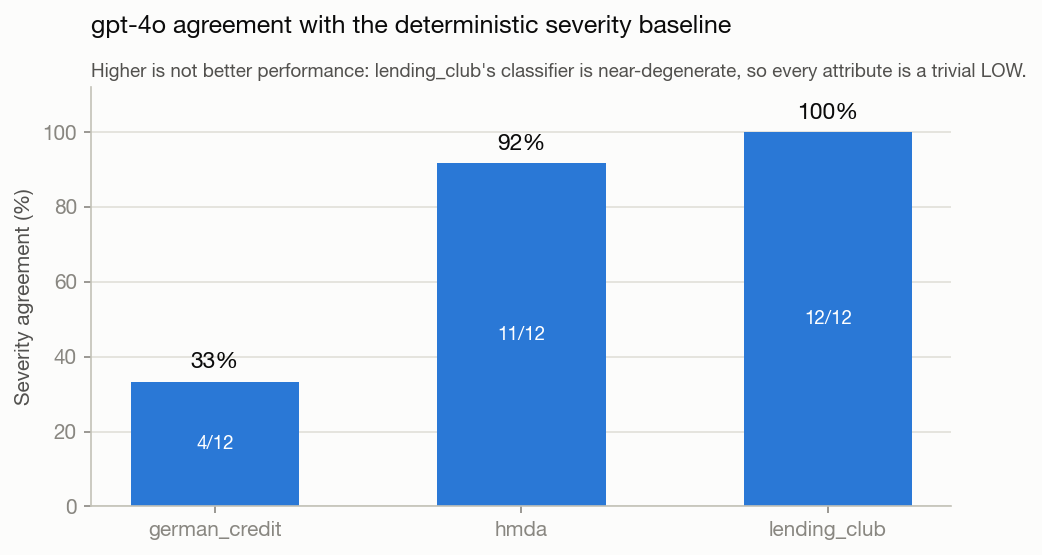


=== track_q_strategy_behaviour.png ===


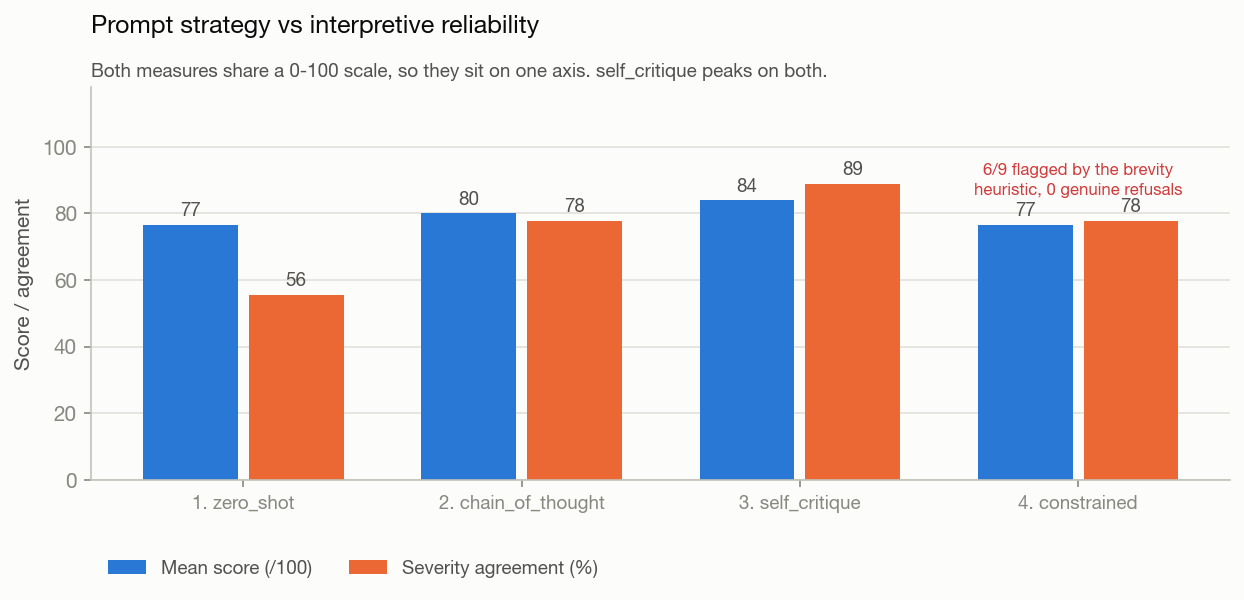


=== track_q_severity_matrix.png ===


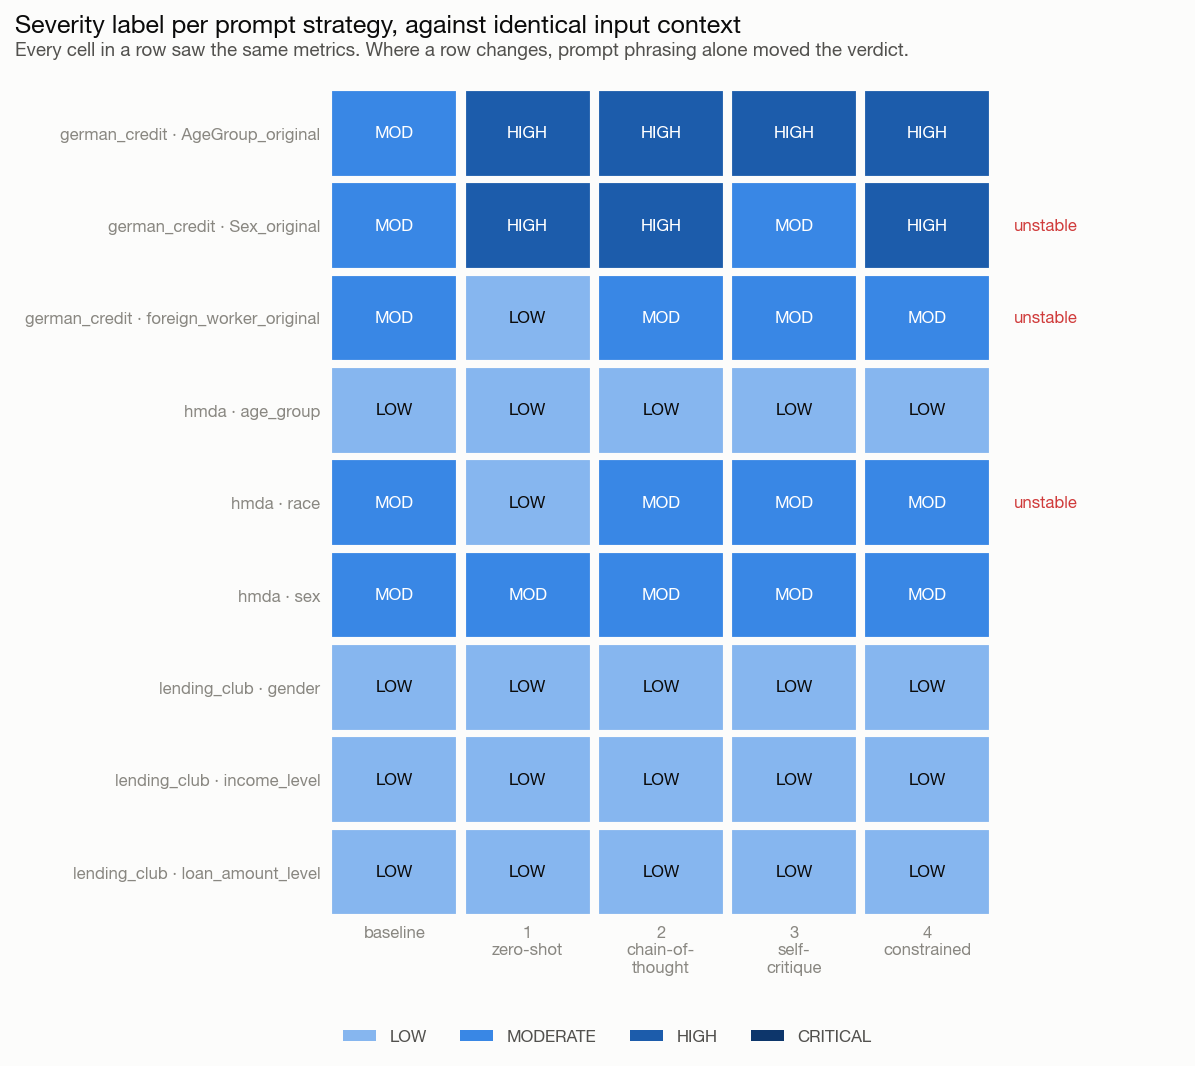


=== track_q_grounding_effect.png ===


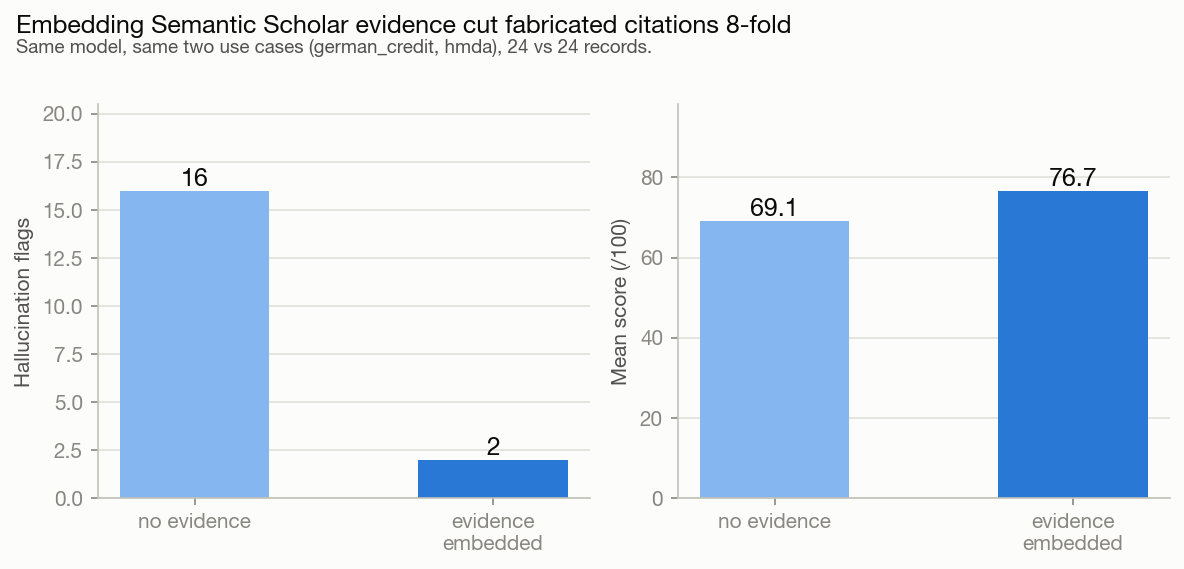

In [21]:
from IPython.display import Image, display
figs = ["track_q_agreement_by_usecase.png", "track_q_strategy_behaviour.png",
        "track_q_severity_matrix.png", "track_q_grounding_effect.png"]
for name in figs:
    p = ROOT / "artifacts" / "visualizations" / name
    if p.exists():
        print(f"\n=== {name} ===")
        display(Image(filename=str(p)))
    else:
        print(f"(missing: {name} — regenerate with scripts/visualize_track_q.py)")

In [22]:
led = json.loads((ROOT / "artifacts/llm_benchmark/spend_ledger.json").read_text())
by = {}
for e in led["entries"]:
    k = e.get("track", "Q")
    by[k] = by.get(k, 0.0) + e["cost_usd"]
print(f"Total spend: ${led['total_usd']:.4f}  (cap ${led['max_cost_usd']:.2f})")
for k in sorted(by):
    print(f"   track {k:8s} ${by[k]:.4f}")
print(f"   + pre-freeze legacy run (predates the ledger): $0.1125")
print(f"   PROGRAM TOTAL: ${led['total_usd'] + 0.1125:.4f}")

Total spend: $0.5969  (cap $15.00)
   track H        $0.3514
   track H-judge  $0.0181
   track Q        $0.2274
   + pre-freeze legacy run (predates the ledger): $0.1125
   PROGRAM TOTAL: $0.7094


---
## Summary

| Layer | Owns | Trustworthy? |
|---|---|---|
| Deterministic pipeline | metrics, severity thresholds | Yes — reproducible by construction |
| LLM interpretation | decision-context narrative | Only when grounded in retrieved evidence |
| LLM severity labels | — | **No** — 3 of 9 pairs moved under paraphrase |

The architecture that survives the evidence: **Python owns the numbers and the
thresholds, the model owns the interpretation, and the interpretation is gated
on evidence the model did not invent.**

Reproduce everything:

```bash
make test                                        # 46 unit tests, no key
python3.11 run_pipeline.py --datasets german_credit hmda lending_club --steps fairness qualitative
python3.11 scripts/report_track_q.py             # Track Q tables
python3.11 scripts/evaluate_track_h.py           # Track H gates (add --judge for the rubric)
python3.11 scripts/visualize_track_q.py          # figures
make paper                                       # the NeurIPS draft
```